<a href="https://colab.research.google.com/github/Saransh-Basu-01/Understanding-Deep-learning-/blob/main/Shallow_Neural_Networks3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [57]:
import math

def number_regions(Di, D):
    # Implement Zaslavsky's formula
    # N = sum_{k=0}^{Di} C(D, k)
    N = 0
    for k in range(Di + 1):
        N += math.comb(D, k)
    return N

In [58]:

# Calculate the number of regions for 2D input (Di=2) and 3 hidden units (D=3) as in figure 3.8j
N = number_regions(2, 3)
print(f"Di=2, D=3, Number of regions = {int(N)}, True value = 7")

Di=2, D=3, Number of regions = 7, True value = 7


In [59]:
N = number_regions(10, 50)
print(f"Di=10, D=50, Number of regions = {int(N)}, True value = 13432735556")

Di=10, D=50, Number of regions = 13432735556, True value = 13432735556


In [60]:
try:
  N = number_regions(10, 8)
  print(f"Di=10, D=8, Number of regions = {int(N)}, True value = 256")
except Exception as error:
    print("An exception occurred:", error)

Di=10, D=8, Number of regions = 256, True value = 256


Counting regions for 1 input dimensions
Counting regions for 5 input dimensions
Counting regions for 10 input dimensions
Counting regions for 50 input dimensions
Counting regions for 100 input dimensions


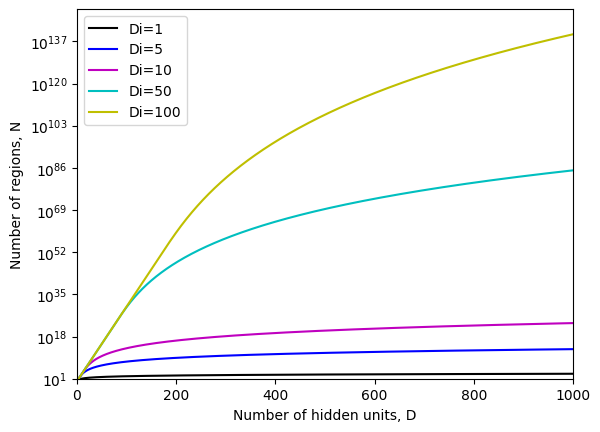

In [61]:
# Now let's plot the graph from figure 3.9a
dims = np.array([1,5,10,50,100])
regions = np.zeros((dims.shape[0], 1000))
for c_dim in range(dims.shape[0]):
    D_i = dims[c_dim]
    print (f"Counting regions for {D_i} input dimensions")
    for D in range(1000):
        regions[c_dim, D] = number_regions(np.min([D_i,D]), D)

fig, ax = plt.subplots()
ax.semilogy(regions[0,:],'k-')
ax.semilogy(regions[1,:],'b-')
ax.semilogy(regions[2,:],'m-')
ax.semilogy(regions[3,:],'c-')
ax.semilogy(regions[4,:],'y-')
ax.legend(['Di=1', 'Di=5', 'Di=10', 'Di=50', 'Di=100'])
ax.set_xlabel("Number of hidden units, D")
ax.set_ylabel("Number of regions, N")
plt.xlim([0,1000])
plt.ylim([1e1,1e150])
plt.show()

In [64]:
def number_parameters(D_i, D):
    # Parameters from input to hidden layer
    # Each of D hidden units has (D_i + 1) parameters (weights + bias)
    input_to_hidden = D * (D_i + 1)

    # Parameters from hidden to output layer
    # Output has (D + 1) parameters (D weights + 1 bias)
    hidden_to_output = D + 1

    # Total parameters
    N = input_to_hidden + hidden_to_output

    return N

Computing for 1 input dimensions
Computing for 5 input dimensions
Computing for 10 input dimensions
Computing for 50 input dimensions
Computing for 100 input dimensions


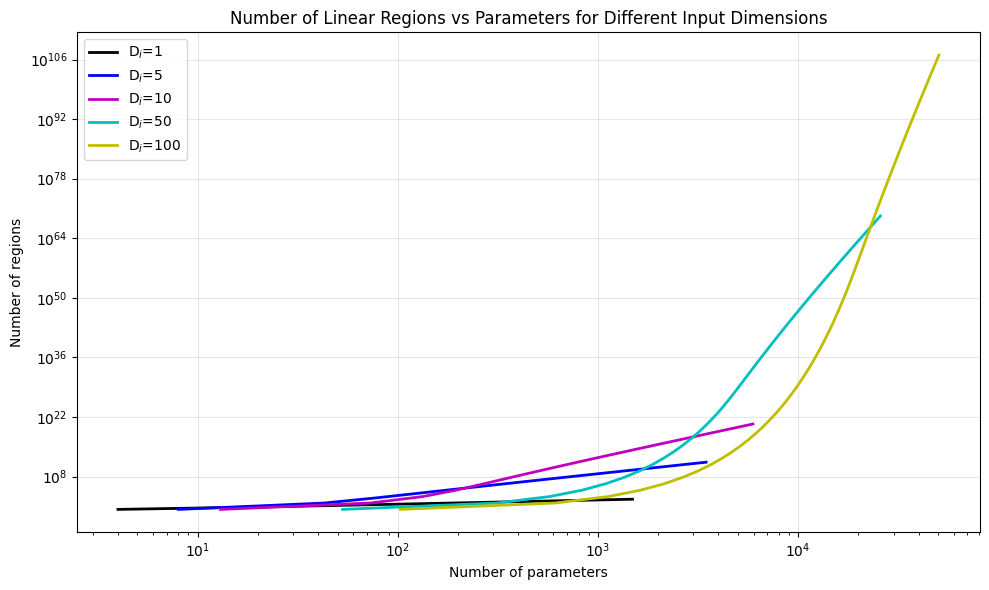

In [65]:
# Now let's compute and plot the number of regions as a function of the number of parameters
# For different input dimensions

# Define input dimensions to analyze
input_dims = np.array([1, 5, 10, 50, 100])
colors = ['k-', 'b-', 'm-', 'c-', 'y-']  # Black, Blue, Magenta, Cyan, Yellow

# Create figure for the combined plot
fig, ax = plt.subplots(figsize=(10, 6))

# For each input dimension
for idx, D_i in enumerate(input_dims):
    print(f"Computing for {D_i} input dimensions")

    # Range of hidden units to try
    D_values = np.arange(1, 500, 5)  # Try up to 500 hidden units

    # Store results
    region_counts = []
    param_counts = []

    for D in D_values:
        # Number of regions using Zaslavsky's formula
        regions = number_regions(np.min([D_i, D]), D)

        # Number of parameters for this configuration
        params = number_parameters(D_i, D)

        region_counts.append(regions)
        param_counts.append(params)

    # Plot regions vs parameters on log-log scale
    ax.loglog(param_counts, region_counts, colors[idx],
              label=f'D$_i$={D_i}', linewidth=2)

# Add labels and legend
ax.set_xlabel('Number of parameters')
ax.set_ylabel('Number of regions')
ax.set_title('Number of Linear Regions vs Parameters for Different Input Dimensions')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
N = number_parameters(10, 8)
print(f"Di=10, D=8, Number of parameters = {int(N)}, True value = 97")